# NUFHT Batch Example (Vectorized)
This notebook demonstrates a simple, vectorized call to `nufht_batch()` using the `_pynufht` Python extension.

We build a batched input matrix with shape `(m, batch)` and call `nufht_batch` once to compute all transforms.

## 1. Import Dependencies and Configure Environment
We import NumPy and the `_pynufht` extension that provides `nufht_batch`.

In [2]:
import os
import sys
import subprocess

# Ensure extension is built in ../python (relative to this notebook)
py_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "python"))
so_exists = any(name.startswith("_pynufht") and name.endswith(".so") for name in os.listdir(py_dir))
if not so_exists:
    subprocess.check_call([sys.executable, "setup.py", "build_ext", "--inplace"], cwd=py_dir)

# Add ../python to sys.path so we can import the built extension
if py_dir not in sys.path:
    sys.path.insert(0, py_dir)

print("Python module path:", py_dir)

Python module path: /Users/kamion/SCIENCE/nufht/python


In [3]:
import numpy as np
import _pynufht as pn

print("_pynufht version loaded, functions:", [n for n in dir(pn) if n.startswith("nufht")])

_pynufht version loaded, functions: ['nufht', 'nufht_batch', 'nufht_batch_loop']


## 2. Create Synthetic Input Batch
We load Gauss–Legendre points, rescale to $[0, r_{\max}]$, then build a batched input matrix with two columns (two different orders $\mu$).

In [8]:
# Load GL points from project data
# Note: run from notebooks/ so ../data/gl1000 is valid
path = "../data/gl1000"
gl = np.loadtxt(path)
absc = gl[:, 0].copy()
wght = gl[:, 1].copy()

# Rescale from [-1,1] to [0, rmax]
rmax = 10.0
absc = (rmax / 2.0) * (absc + 1.0)
wght *= (rmax / 2.0)

m = len(absc)
Nk = 100
kmax = 10.0
k_grid = kmax * (np.arange(1, Nk + 1) / Nk)

# Use a single mu for all batch columns (nufht_batch uses one nu for the batch)
mu = 0.0
scales = np.array([1.0, 0.5])
batch = len(scales)

# Vectorized: base function for this mu
rs_col = absc[:, None]
base = (rs_col ** (mu + 1.0)) * np.exp(-0.5 * rs_col**2) * wght[:, None]

# Two columns are scaled versions of the same base function
cs = base * scales[None, :]

# Ensure Fortran order for efficient nufht_batch
cs_F = np.asfortranarray(cs)

cs_F.shape, k_grid.shape

((1000, 2), (100,))

## 3. Call nufht_batch() with Vectorized Inputs
We call `nufht_batch` once to compute both transforms.

In [9]:
g_batch = pn.nufht_batch(mu, absc, cs_F, k_grid, tol=1e-8)

# g_batch has shape (n, batch)
g_batch.shape

(100, 2)

## 4. Validate Shapes and Inspect Output
We compare each column to the analytic transform $\Gamma(\mu+1) k^{\mu} e^{-k^2/2}$ and report max errors.

In [10]:
from math import gamma

# Analytic base transform for this mu
base_analytic = gamma(mu + 1.0) * (k_grid ** mu) * np.exp(-0.5 * k_grid**2)

# Each column should match the corresponding scale
analytic = base_analytic[:, None] * scales[None, :]

abs_err = np.abs(g_batch - analytic)
rel_err = abs_err / (np.abs(analytic) + 1e-16)

print("max abs err per batch:", abs_err.max(axis=0))
print("max rel err per batch:", rel_err.max(axis=0))
print("g_batch[:5, :]:\n", g_batch[:5, :])

max abs err per batch: [9.95870053e-14 4.97935027e-14]
max rel err per batch: [373.48225763 186.74130891]
g_batch[:5, :]:
 [[0.99501248 0.49750624]
 [0.98019867 0.49009934]
 [0.95599748 0.47799874]
 [0.92311635 0.46155817]
 [0.8824969  0.44124845]]


### Log-scale comparison plot
We plot the magnitude of the numeric result and the analytic reference on a log scale for each batch column.

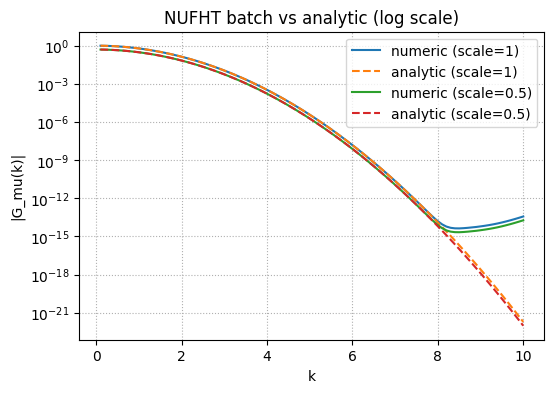

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
for i, s in enumerate(scales):
    ax.plot(k_grid, np.abs(g_batch[:, i]), label=f"numeric (scale={s:g})")
    ax.plot(k_grid, np.abs(analytic[:, i]), "--", label=f"analytic (scale={s:g})")

ax.set_yscale("log")
ax.set_xlabel("k")
ax.set_ylabel("|G_mu(k)|")
ax.set_title("NUFHT batch vs analytic (log scale)")
ax.grid(True, which="both", ls=":")
ax.legend()
plt.show()

## 5.Fresnel lensing integral F(w, y) using `nufht_batch`
We compute $F(w,y)$ using the cored isothermal halo used in Fig. 2(D) of arXiv:2210.05658, for 100 values of $w\in[0.1,10]$ and 150 values of $y\in[0,1]$.  The integral is done with a Gauss-Legendre quadrature up to $R=\sqrt{n_{gl}/(2w)}$ with $n_{gl}=1000$ roots. Real and imaginary parts are evaluated simultaneously via a two-column batch

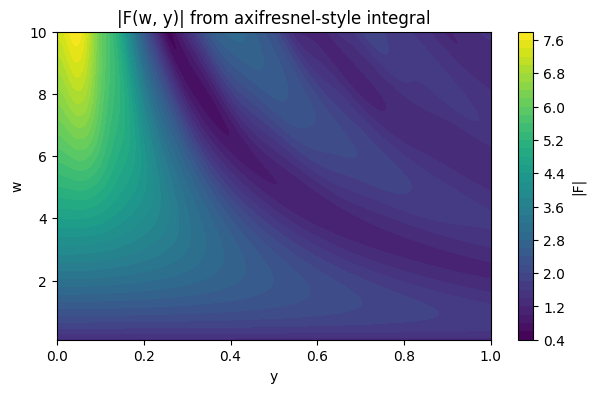

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Load base GL points (on [-1, 1]) and weights
n_gl = 1000
base_gl = np.loadtxt("../data/gl1000")
absc0 = base_gl[:, 0].copy()
wght0 = base_gl[:, 1].copy()

# w and y grids
w_grid = np.linspace(0.1, 10.0, 100)
y_grid = np.linspace(0.0, 1.0, 150)

# Helper: compute c_j(w) vectorized (matches axifresnel.c)
def compute_cj_vec(w, u_j, xi_j, u_max_w):
    if u_max_w <= 0.0:
        return np.zeros_like(u_j, dtype=np.complex128)
    du = 0.02 * u_max_w
    if du <= 0.0:
        du = 1e-12
    window_u = 0.5 * (1.0 - np.tanh((u_j - u_max_w) / du))

    x = u_j / w
    Rmax = u_max_w / w
    arg = x - 0.75 * Rmax
    numerator = 0.5 * (1.0 - np.tanh(arg))

    xc = 0.05
    psi_x = np.sqrt(x * x + xc * xc) + xc * np.log((2.0 * xc) / (np.sqrt(x * x + xc * xc) + xc))
    psi_x *= numerator

    phaseA = np.exp(1j * (u_j * u_j) / (2.0 * w))
    phasePsi = np.exp(-1j * w * psi_x)
    return window_u * xi_j * u_j * phaseA * (phasePsi - 1.0)

# Allocate output F(w,y)
F = np.zeros((len(w_grid), len(y_grid)), dtype=np.complex128)

# Loop over w values; use nufht_batch with batch=2 (real & imag)
for iw, w in enumerate(w_grid):
    R = np.sqrt(n_gl / (2.0 * w))
    u_max = w * R  # per-w cutoff

    # Rescale GL points to [0, u_max]
    u_j = (u_max / 2.0) * (absc0 + 1.0)
    xi_j = (u_max / 2.0) * wght0

    cj = compute_cj_vec(w, u_j, xi_j, u_max)

    # Pack real/imag into 2-column batch
    cs = np.column_stack([cj.real, cj.imag])
    cs_F = np.asfortranarray(cs)

    # nufht_batch for nu=0 (J0)
    g_batch = pn.nufht_batch(0.0, u_j, cs_F, y_grid, tol=1e-8)
    G = g_batch[:, 0] + 1j * g_batch[:, 1]

    prefac = np.exp(1j * w * y_grid * y_grid / 2.0) / (1j * w)
    F[iw, :] = 1.0 + prefac * G

# Contour plot of |F(w,y)| with y on horizontal axis and w vertical
Y, W = np.meshgrid(y_grid, w_grid, indexing="xy")
fig, ax = plt.subplots(figsize=(7, 4))
levels = 40
cf = ax.contourf(Y, W, np.abs(F), levels=levels, cmap="viridis")
ax.set_xlabel("y")
ax.set_ylabel("w")
ax.set_title("|F(w, y)| from axifresnel-style integral")
fig.colorbar(cf, ax=ax, label="|F|")
plt.show()

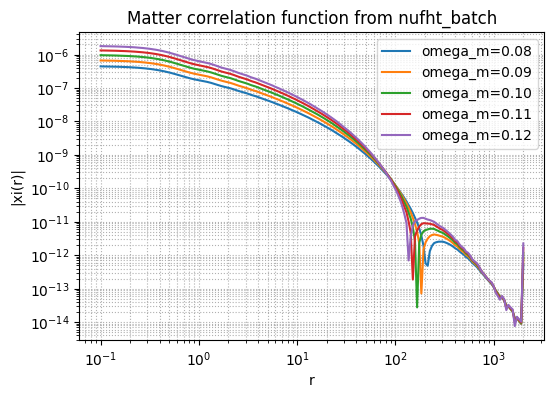

In [20]:
# Cosmological matter correlation function xi(r) from P(k)=k^3 T^2(k)
# xi(r) = 1/sqrt(r) * ∫ d ln k k^{5/2} P(k) J_{1/2}(k r)

# Transfer function (BBKS-style) from the provided snippet
# T(k) = [ln(1+2.34 q)/(2.34 q)] * [1+3.89 q + (16.1 q)^2 + (5.46 q)^3 + (6.71 q)^4]^(-1/4)

import matplotlib.pyplot as plt

def transfer_T(k, omega_m):
    q = k / omega_m
    L = np.log(1.0 + 2.34 * q) / (2.34 * q)
    C = 1.0 + 3.89 * q + (16.1 * q) ** 2 + (5.46 * q) ** 3 + (6.71 * q) ** 4
    return L * C ** (-0.25)

# Quadrature in ln k
n_gl = 10000
absc = np.loadtxt("../data/gl10000")[:, 0]
wght = np.loadtxt("../data/gl10000")[:, 1]
smin, smax = -9.0, 2.0  # ln k range
s = (smax - smin) / 2.0 * (absc + 1.0) + smin
ws = (smax - smin) / 2.0 * wght
k = np.exp(s)

# r grid
r_grid = np.logspace(-1, np.log10(2000.0), 200)  # 0.1 to 2000

# Batch over omega_m values
omega_m_vals = np.array([0.08, 0.09, 0.10, 0.11, 0.12])
batch = len(omega_m_vals)

# Build cs matrix: cs_j = w_s * k^{5/2} * P(k)
# with P(k)=k T(k)^2 => k^{7/2} T(k)^2
cs = np.empty((n_gl, batch), dtype=np.float64)
for i, om in enumerate(omega_m_vals):
    T = transfer_T(k, om)
    Pk = k * T * T
    cs[:, i] = ws * (k ** 2.5) * Pk  # k^{5/2} * P(k) = k^{7/2} T^2

cs_F = np.asfortranarray(cs)

# Hankel order nu = 1/2
nu = 0.5
G_batch = pn.nufht_batch(nu, k, cs_F, r_grid, tol=1e-8)

# xi(r) = G(r) / sqrt(r)
xi = G_batch / np.sqrt(r_grid)[:, None]/ (2.0 * np.pi)**(3/2)

# Plot xi(r) on log-log axes
fig, ax = plt.subplots(figsize=(6, 4))
for i, om in enumerate(omega_m_vals):
    ax.plot(r_grid, np.abs(xi[:, i]), label=f"omega_m={om:.2f}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("r")
ax.set_ylabel("|xi(r)|")
ax.set_title("Matter correlation function from nufht_batch")
ax.grid(True, which="both", ls=":")
ax.legend()
plt.show()

In [22]:
# Timing: measure nufht_batch() wall time
import time

n_repeat = 3
times = []
for _ in range(n_repeat):
    t0 = time.perf_counter()
    _ = pn.nufht_batch(nu, k, cs_F, r_grid, tol=1e-8)
    t1 = time.perf_counter()
    times.append(t1 - t0)

print(f"nufht_batch time (s): min={min(times):.4g}, mean={np.mean(times):.4g}, max={max(times):.4g} over {n_repeat} runs")

nufht_batch time (s): min=0.005787, mean=0.007182, max=0.009203 over 3 runs


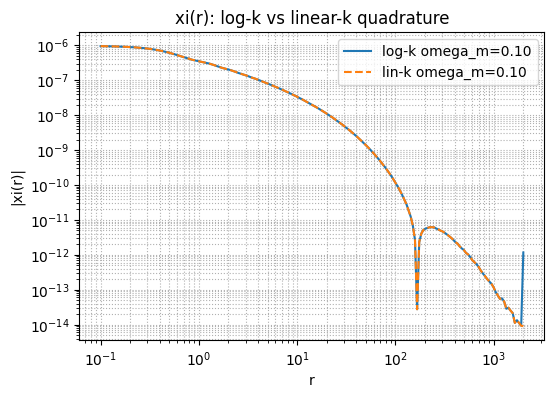

In [21]:
# Linear-k quadrature version of the same xi(r) integral
# Map GL nodes from [-1,1] to [k_min, k_max] linearly
k_min_lin = np.exp(smin)
k_max_lin = np.exp(smax)
k_lin = (k_max_lin - k_min_lin) / 2.0 * (absc + 1.0) + k_min_lin
w_lin = (k_max_lin - k_min_lin) / 2.0 * wght

# Build cs matrix for linear-k quadrature: ∫ dk k^{3/2} P(k) J_{1/2}(k r)
# Starting from ∫ d ln k k^{5/2} P(k) J_{1/2}(k r) = ∫ dk k^{3/2} P(k) J_{1/2}(k r)
cs_lin = np.empty((n_gl, batch), dtype=np.float64)
for i, om in enumerate(omega_m_vals):
    T_lin = transfer_T(k_lin, om)
    Pk_lin = k_lin * T_lin * T_lin
    cs_lin[:, i] = w_lin * (k_lin ** 1.5) * Pk_lin  # k^{3/2} * P(k)

cs_lin_F = np.asfortranarray(cs_lin)
G_batch_lin = pn.nufht_batch(nu, k_lin, cs_lin_F, r_grid, tol=1e-8)
xi_lin = G_batch_lin / np.sqrt(r_grid)[:, None] / (2.0 * np.pi) ** (3/2)

# Plot xi_lin(r) and compare to the log-k quadrature result (omega_m=0.10)
target_om = 0.10
idx = np.argmin(np.abs(omega_m_vals - target_om))
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(r_grid, np.abs(xi[:, idx]), label=f"log-k omega_m={omega_m_vals[idx]:.2f}")
ax.plot(r_grid, np.abs(xi_lin[:, idx]), "--", label=f"lin-k omega_m={omega_m_vals[idx]:.2f}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("r")
ax.set_ylabel("|xi(r)|")
ax.set_title("xi(r): log-k vs linear-k quadrature")
ax.grid(True, which="both", ls=":")
ax.legend()
plt.show()

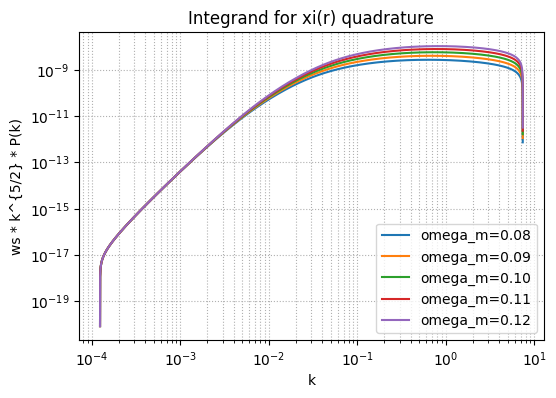

In [13]:
# Plot the integrand: ws * (k ** 2.5) * Pk for each omega_m
fig, ax = plt.subplots(figsize=(6, 4))
for i, om in enumerate(omega_m_vals):
    ax.plot(k, cs[:, i], label=f"omega_m={om:.2f}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("k")
ax.set_ylabel("ws * k^{5/2} * P(k)")
ax.set_title("Integrand for xi(r) quadrature")
ax.grid(True, which="both", ls=":")
ax.legend()
plt.show()

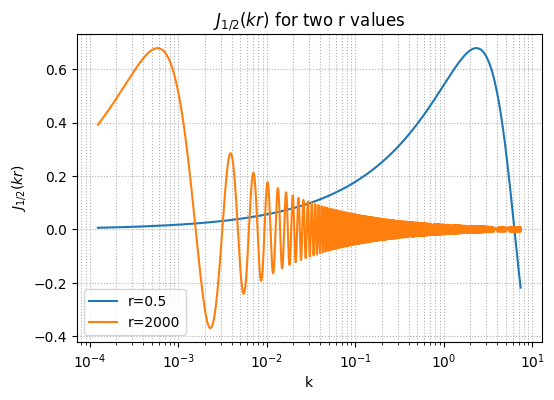

In [14]:
# Plot J_{1/2}(k r) for r=0.5 and r=2000
r_vals = [0.5, 2000.0]
k_plot = k  # use the same k grid as in the quadrature

def j_half(x):
    return np.sqrt(2.0 / (np.pi * x)) * np.sin(x)

fig, ax = plt.subplots(figsize=(6, 4))
for r in r_vals:
    x = k_plot * r
    ax.plot(k_plot, j_half(x), label=f"r={r:g}")

ax.set_xscale("log")
ax.set_xlabel("k")
ax.set_ylabel(r"$J_{1/2}(k r)$")
ax.set_title(r"$J_{1/2}(k r)$ for two r values")
ax.grid(True, which="both", ls=":")
ax.legend()
plt.show()

fht k-range: 1e-06 to 100.00000000000017
fht r-range: 0.1 to 10000000.000000019
Median relative error per omega_m (overlap): [0.46816528 0.45759971 0.44832058 0.43436568 0.42344996]


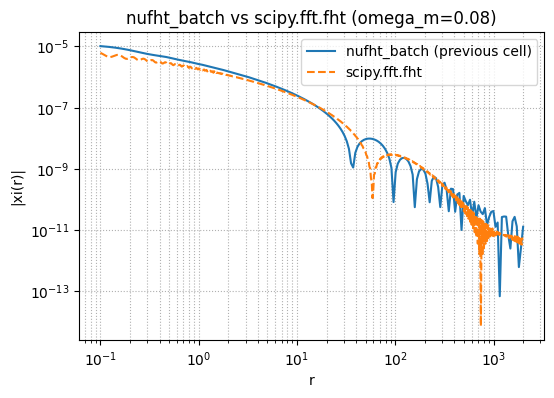

In [8]:
# Compare with SciPy's FFTLog-based Hankel transform (scipy.fft.fht)
try:
    from scipy.fft import fht
except Exception as exc:
    print("SciPy is not available in this environment:", exc)
    print("Install scipy to run this comparison.")
else:
    # Ensure nufht_batch result from the previous cell is available
    if "xi" not in globals():
        raise RuntimeError("Run the previous cell to compute xi before this comparison.")

    # Build a broader/denser log-k grid for FFTLog
    n_fft = 1024
    k_min = 1e-6
    k_max = 1e2
    dln = np.log(k_max / k_min) / (n_fft - 1)
    k_fft = k_min * np.exp(np.arange(n_fft) * dln)

    # Match the r grid via the FFTLog offset; r_fft is log-spaced with the same dln
    r_min = r_grid[0]
    offset = np.log(k_min * r_min)
    r_fft = r_min * np.exp(np.arange(n_fft) * dln)
    print("fht k-range:", k_fft[0], "to", k_fft[-1])
    print("fht r-range:", r_fft[0], "to", r_fft[-1])

    # Build f(k) = k^{5/2} P(k) for each omega_m
    f_k = np.empty((n_fft, batch), dtype=np.float64)
    for i, om in enumerate(omega_m_vals):
        T = transfer_T(k_fft, om)
        Pk = k_fft * T * T
        f_k[:, i] = (k_fft ** 2.5) * Pk

    # SciPy fht for each batch column
    G_fft = np.column_stack([fht(f_k[:, i], dln, mu=nu, offset=offset) for i in range(batch)])
    xi_fft = G_fft / np.sqrt(r_fft)[:, None]

    # Compare against nufht_batch result from the previous cell (no recomputation)
    mask = (r_fft >= r_grid[0]) & (r_fft <= r_grid[-1])
    log_r_grid = np.log(r_grid)
    log_r_fft = np.log(r_fft[mask])

    rel_list = []
    for i in range(batch):
        xi_nufht_abs = np.abs(xi[:, i])
        xi_nufht_interp = np.interp(log_r_fft, log_r_grid, xi_nufht_abs)
        xi_fft_abs = np.abs(xi_fft[mask, i])
        rel_list.append(np.median(np.abs(xi_nufht_interp - xi_fft_abs) / (xi_fft_abs + 1e-30)))
    print("Median relative error per omega_m (overlap):", np.array(rel_list))

    # Plot comparison for the first omega_m on the overlapping range
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(r_grid, np.abs(xi[:, 0]), label="nufht_batch (previous cell)")
    ax.plot(r_fft[mask], np.abs(xi_fft[mask, 0]), "--", label="scipy.fft.fht")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("r")
    ax.set_ylabel("|xi(r)|")
    ax.set_title(f"nufht_batch vs scipy.fft.fht (omega_m={omega_m_vals[0]:.2f})")
    ax.grid(True, which="both", ls=":")
    ax.legend()
    plt.show()